In [1]:
import os
# Fix for "multiple OpenMP runtime" error on Windows
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

notebook_dir = r"c:\Users\zhibo.zhu\OneDrive - UIH Group\Documents\Jupyter\transformer_MRI"
os.chdir(notebook_dir)
print('Changed CWD to', os.getcwd())

import sys
from pathlib import Path
fast_mri_path = Path('../fastMRI-main').resolve()
if str(fast_mri_path) not in sys.path:
    sys.path.append(str(fast_mri_path))


Changed CWD to c:\Users\zhibo.zhu\OneDrive - UIH Group\Documents\Jupyter\transformer_MRI


In [2]:
import pathlib
# from data import subsample
from fastmri.data import transforms, mri_data
# from data.mri_data import SliceDataset

# Create a mask function
# mask_func = subsample.RandomMaskFunc(
#     center_fractions=[0.08, 0.04],
#     accelerations=[4, 8]
# )

def data_transform(kspace, mask, target, data_attributes, filename, slice_num):
    # Transform the data into appropriate format
    # Here we simply mask the k-space and return the result
    kspace = transforms.to_tensor(kspace)
    # masked_kspace = transforms.apply_mask(kspace, mask_func)
    return kspace

path_to_data = r'e:\fastMRI\data\multicoil_train'
dataset = mri_data.SliceDataset(
    root=pathlib.Path(path_to_data),
    transform=data_transform,
    challenge='multicoil'
)

C:\Users\zhibo.zhu\OneDrive - UIH Group\Documents\Jupyter\fastMRI-main\fastmri\__init__.py:16: UserWarning: Could not retrieve fastmri version!
  warnings.warn("Could not retrieve fastmri version!")


Single slice ksp tensor shape: torch.Size([16, 320, 320])


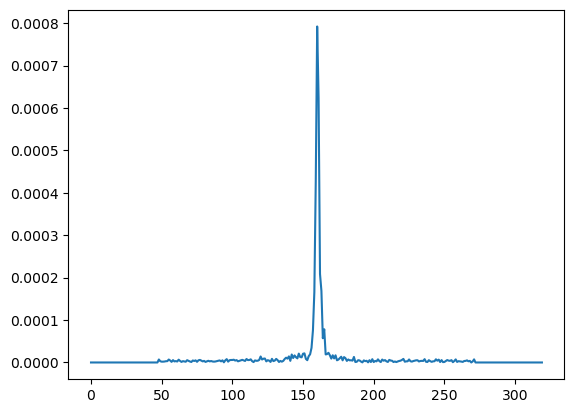

Sampled 224 PE lines.


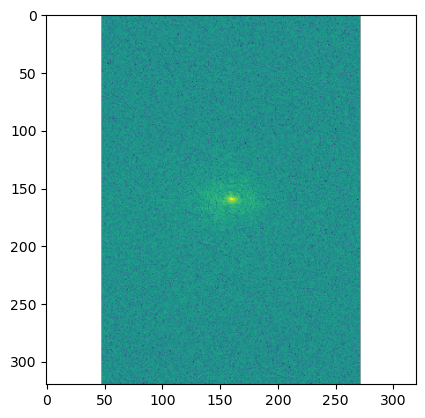

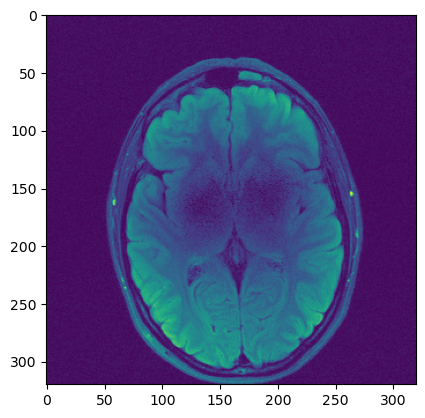

Sampling mask shape: torch.Size([1, 320, 320])


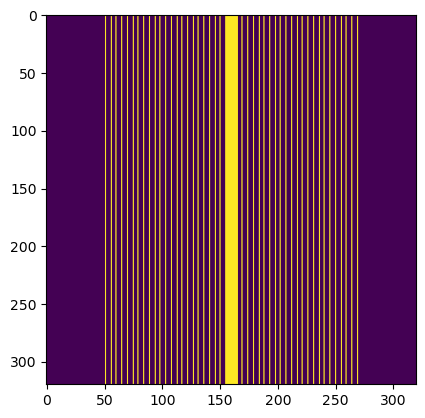

In [28]:
import matplotlib.pyplot as plt
import torch
import torch
from fastmri.data import subsample

# kspace sanity check.
# print(f"Single slice ksp tensor shape: {dataset[0].shape}")
ksp = dataset[0]
ksp = torch.flip(torch.complex(ksp[:, ::2, :, 0], ksp[:, ::2, :, 1]), dims=[1])
print(f"Single slice ksp tensor shape: {ksp.shape}")
_, NADC, NPE = ksp.shape

plt.figure()
plt.plot(torch.squeeze(torch.abs(ksp[0, 160, :])))
plt.show()
print(f"Sampled {torch.sum(torch.abs(ksp[0, 160, :]) != 0)} PE lines.")
NPE_true = torch.sum(torch.abs(ksp[0, 160, :]) != 0)

plt.figure()
plt.imshow(torch.log10(torch.abs(ksp[0, ...])))
plt.show()

imgc_zero_filled = torch.fft.fftshift(torch.fft.ifft2(torch.fft.ifftshift(ksp, dim=(1, 2))), dim=(1, 2))
img_zero_filled = torch.sqrt(torch.sum(imgc_zero_filled ** 2, dim=0))
# imgc_zero_filled = torch.fft.ifft2(ksp)

plt.figure()
plt.imshow(torch.abs(img_zero_filled))
plt.show()

# ksp_zero_filled = torch.fft.ifftshift(torch.fft.fft2(torch.fft.fftshift(imgc_zero_filled), dim=(1, 2)), dim=(1, 2))

# plt.figure()
# plt.imshow(torch.log10(torch.abs(ksp_zero_filled[0, ...])))
# plt.show()

# Create some subsampling mask.
# Fast MRI subsampling mask handler.
mask_func = subsample.create_mask_for_mask_type(
    mask_type_str='equispaced_fraction',
    center_fractions=[0.05, 0.05],
    accelerations=[4, 4],
)

padding = (NADC - NPE_true) // 2 # (320 - 224) / 2
ksp_test = torch.ones_like(dataset[0])
ksp_test = ksp_test[0, :, padding:-padding, 0].unsqueeze(0)
masked_ksp, mask, cnt = transforms.apply_mask(ksp_test.transpose(-2, -1), mask_func=mask_func, seed=42)
masked_ksp = masked_ksp.transpose(-2, -1)
mask = mask.transpose(-2, -1)
mask = torch.cat([torch.zeros(size=[1, 1, padding]), mask, torch.zeros(size=[1, 1, padding])], dim=2)
mask = mask.repeat(1, NADC, 1)
print(f"Sampling mask shape: {mask.shape}")

plt.figure()
plt.imshow(mask[0, ...])
plt.show()

In [29]:
print(ksp_test.shape)
print(mask.shape)

torch.Size([1, 640, 224])
torch.Size([1, 320, 320])


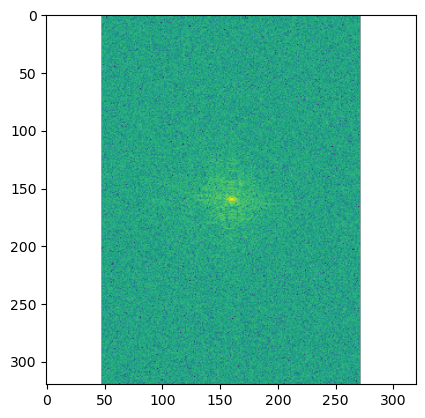

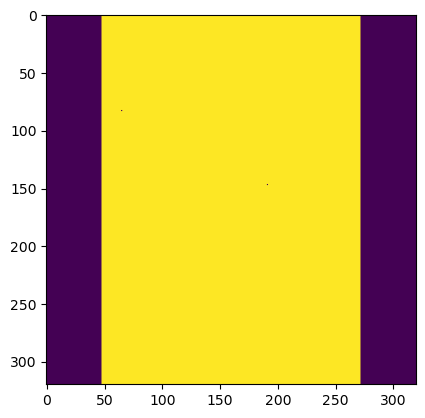

In [5]:
import numpy as np
from transformer import transformer
import torch.nn as nn

W, H = 320, 320
pos = np.mgrid[0:W, 0:H]
# ksp_transformer = transformer(input_channel=2, output_channel=256, bias=False, pos=pos, d_model=256, N=2, num_heads=4, W=W, H=H, activition=nn.ReLU, approach='sine', dropout_emb=0.0, dropout_enc=0.0, dropout_dec=0.0)

NC, NADC, NPE, _ = dataset[0].shape
ksp_list = []
for ii in range(10):
    ksp = dataset[ii]
    ksp_list.append(ksp[:, ::2, :, :])
ksp_batch = torch.cat(ksp_list, dim=0)
omega = (ksp_batch != 0)
omega = omega[..., 0]

Nbatch = 33
plt.figure()
plt.imshow(torch.log10(torch.abs(ksp_batch[Nbatch, :, :, 1])))
plt.show()

plt.figure()
plt.imshow(omega[Nbatch, ...])
plt.show()

In [46]:
ksp_us = ksp_batch[0, ...].unsqueeze(0)
print(ksp_us.shape)
print(mask.bool().unsqueeze(-1).repeat(1, 1, 1, 2).shape)
ksp_us = torch.masked_select(ksp_us, mask.bool().unsqueeze(-1).repeat(1, 1, 1, 2))
ksp_us = ksp_us.view(1, -1, 2)
print(ksp_us.shape)

torch.Size([1, 320, 320, 2])
torch.Size([1, 320, 320, 2])
torch.Size([1, 17600, 2])


In [47]:
W, H = 320, 320
pos = np.mgrid[0:W, 0:H]
ksp_transformer = transformer(input_channel=2, output_channel=256, bias=False, pos=pos, d_model=256, omega=mask, N=6, num_heads=4, W=W, H=H, activition=nn.ReLU, approach='sine', dropout_emb=0.0, dropout_enc=0.0, dropout_dec=0.0)

In [ ]:
# Memory issues. The reference framework constructs sequences using tokes per k-space sample. This results in 102400 tokens per 2D k-space.
# As reported, the reference framework used 4 RTX 3090 for training.
# As a result, future work can  pay more attention on improved attention mechanism between k-space lines instead between k-space samples.
tt = ksp_transformer(ksp_us)

RuntimeError: [enforce fail at alloc_cpu.cpp:117] data. DefaultCPUAllocator: not enough memory: you tried to allocate 10485760000 bytes.

In [ ]:
from ksp_transformer_dataset import ksp_transformer_train_dataset
from torch.utils.data import DataLoader

train_dataset = ksp_transformer_train_dataset(input_data, target_data)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)

RuntimeError: [enforce fail at alloc_cpu.cpp:117] data. DefaultCPUAllocator: not enough memory: you tried to allocate 167772160000 bytes.

In [ ]:
import torch.optim as optim
from transformer import transformer, train_model
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

W, H = 320, 320
pos = np.mgrid[0:W, 0:H]
ksp_transformer = transformer(input_channel=2, output_channel=256, bias=False, pos=pos, d_model=256, omega=mask, N=6, num_heads=4, W=W, H=H, activition=nn.ReLU, approach='sine', dropout_emb=0.0, dropout_enc=0.0, dropout_dec=0.0)

criteria_MSE = nn.MSELoss()
optimizer = optim.Adam(ksp_transformer.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5, min_lr=1e-5)

train_model(ksp_transformer, train_loader, optimizer, scheduler, device, criteria_MSE, log_dir="D:/models/ksp_transformer", epochs=300)